# Combining branching processes and Allee effects into an integral projection model to assess invasion risk
**Authors:** James P. Peirce Cynthia S. Tam Joseph J. Parkos Grace L. Loppnow Mark W. Fritts Alison A. Coulter Richard A. Erickson

This notebook reproduces the Silver Carp analyses and figures from Peirce et al. (2026). It is intended as supplementary material. All model logic lives in the companion module IPMbpA.py; this notebook handles parameterization, simulation runs, and visualization only.

**Expected runtimes:**
- Simple simulation: < 1 minute
- Figure 1 (1,000 iterations): ~3-5 minutes
- Figure 2,3a (probabiluty of establishent): ~4-7 minutes each
- Figure 2,3b (time to establishment): ~4-7 minutes each 

## 1. Environmental Setup

### 1.1 Standard libraries:

In [37]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import plotnine as p9
from scipy.special import expit
from random import choices, random 

### 1.2 Custom Module

IPMbpA contains the core IPM-branching-process-Allee model class and stochastic wrapper. See IPMbpA.py for full documentation.

In [38]:
import IPMbpA as ipma

## 2. Silver Carp Parameterization
Silver carp are planktivorous filter feeders native to freshwater systems in eastern Asia (Robison & Buchanan, 2020). Their establishment in the Mississippi River Basin, including the Illinois River, followed escapes from aquaculture facilities in the 1990s (Lohmeyer & Garvey 2009; Robison & Buchanan, 2020), and their continued expansion poses a significant threat to the Great Lakes via the hydrological connection between the Illinois River and Lake Michigan (Cudmore et al. 2012).

**References:**
- Robison, Henry W., and Thomas M. Buchanan. Fishes of Arkansas. University of Arkansas Press, 2020.
- Lohmeyer, Adam M., and James E. Garvey. "Placing the North American invasion of Asian carp in a spatially explicit context." Biological Invasions 11, no. 4 (2009): 905-916.
- Cudmore, Becky, Nicholas E. Mandrak, John M. Dettmers, Duane C. Chapman, Cynthia S. Kolar, and Department of Fisheries and Oceans, Ottawa, ON(Canada); Canadian Science Advisory Secretariat, Ottawa, ON(Canada). Binational ecological risk assessment of bigheaded carps(Hypophthalmichthys spp.) for the Great Lakes Basin. No. 2011/114. DFO, Ottawa, ON(Canada), 2012.

### 2.1 Length Mesh 

In [39]:
min_len = 0.01
max_len = 1.5 
n_len = 50 # number of length bins
length_mesh = np.linspace(min_len, max_len, n_len)
delta_z = np.diff(length_mesh)[0] # width of length bin

### 2.2 Survival
Parameter source: Lorenzen (1996) natural mortality relationship; length-weight from Erickson et al. (2021).

We used an intercept of 1.02 and slope of 3.02, picking the highest values because values were highest near the invasion front.

**Reference:**
- Lorenzen, Kai. "A simple von Bertalanffy model for density-dependent growth in extensive aquaculture, with an application to common carp (Cyprinus carpio)." Aquaculture 142, no. 3-4 (1996): 191-205.
- Erickson, Richard A., Jahn L. Kallis, Alison A. Coulter, David P. Coulter, Ruairí MacNamara, James T. Lamer, Wesley W. Bouska et al. "Demographic rate variability of bighead and silver carps along an invasion gradient." Journal of Fish and Wildlife Management 12, no. 2 (2021): 338-353.


In [40]:
svcp_lw = ipma.length_weight(intercept = 1.02, slope = 3.02)
p_survive = ipma.prob_survival(lw_func = svcp_lw, slope = 3.30, exponent = -0.261)

### 2.3 Growth
Parameter source: von Bertalanffy parameters from Coles (2023), via the MetaIPM package.

**References** 
- Coles, Cameron, Elizabeth Balas, James Peirce, Greg Sandland, and Richard Erickson. "Using integral projection models to explore management strategies for silver carp (Hypophthalmichthys molitrix)." Spora: A Journal of Biomathematics 9, no. 1 (2023): 37-48.
- The MetaIPM package's node [function](https://code.usgs.gov/umesc/quant-ecology/metaipm/-/blob/v1.0.0/MetaIPM/node.py).


In [41]:
von_b_growth = ipma.node(vonB_Linf = 1.224, vonB_K = 0.173, vonB_sigma_k = 0.1)

### 2.4 Maturity
Parameter source: Erickson et al. (2021)

**References**
- Erickson, Richard A., Jahn L. Kallis, Alison A. Coulter, David P. Coulter, Ruairí MacNamara, James T. Lamer, Wesley W. Bouska et al. "Demographic rate variability of bighead and silver carps along an invasion gradient." Journal of Fish and Wildlife Management 12, no. 2 (2021): 338-353.


In [42]:
svcp_mat = ipma.mature(intercept = -7.41, slope = 24.98)

### 2.5 Reference Fish Sizes and Biomass
Adult and subadult length and weight benchmarks used to set initial conditions and Allee thresholds.
**References**
- Garvey, James E., Kelly L. DeGrandchamp, and Christopher J. Williamson. Life history attributes of Asian carps in the upper Mississippi River system. No. ERDCTNANSRP071. (2007).
- Miranda, Leandro E. "Growth patterns of invasive Silver Carp in the Mississippi River basin." Fisheries 50, no. 9 (2025): 391-398

In [43]:
ave_length_adult = 0.867 # Garvey 2007
ave_length_subadult = 0.300 # Miranda 2025

ave_weight_adult = svcp_lw.predict_weight(ave_length_adult)
print(f"Weight of {ave_length_adult} m adult fish: {round(ave_weight_adult, 2)} kg")
ave_weight_subadult = svcp_lw.predict_weight(ave_length_subadult)
print(f"Weight of {ave_length_subadult} m subadult fish: {round(ave_weight_subadult, 2)} kg")

Weight of 0.867 m adult fish: 6.8 kg
Weight of 0.3 m subadult fish: 0.28 kg


### 2.6 Allee Effect and Carrying Capracity Parameters
C_low, C_mid, C_high correspond to Allee biomass thresholds equivalent to 1, 10, and 100 adult fish respectively. K is set large enough that carrying capacity does not constrain the invasion scenarios examined here.

**References:**
- Allen, Linda JS, Jesse F. Fagan, Göran Högnäs, and Henrik Fagerholm. "Population extinction in discrete-time stochastic population models with an Allee effect." Journal of Difference Equations and Applications 11, no. 4-5 (2005): 273-293.

In [44]:
gamma_Allen = 1.837
# Allee effect parameters
C_low = ave_weight_adult*1  # kg = one 1 m fish 
C_mid = ave_weight_adult*10  # kg = ten 1 m fish
C_high = ave_weight_adult*100  # kg = 100 1 m fish
# Carry capacity
K = ave_weight_adult*500
gamma = gamma_Allen/K

## 3. Single Simulation

A single deterministic run to verify model behavior before stochastic analyses.

### 3.1 Settings

In [45]:
# Initial number of fish
n0_fish_adult = 10
#
n0_fish_subadult = ave_weight_adult*10/ave_weight_subadult
print(f"Number of subadult fish with same biomass as {n0_fish_adult} adult fish: {round(n0_fish_subadult, 2)}")
# Allee Threshold
C = C_mid
# Years to simulate
n_time = 50 # consistent with Allen (2005)

Number of subadult fish with same biomass as 10 adult fish: 246.55


### 3.2 Model Run

In [46]:
out = ipma.ipm_bp_allee(
    p_survive = p_survive,
    p_mature = svcp_mat,
    lw_input = svcp_lw,
    gamma = gamma,
    C = C,
    K = K,
    k = 2,
    min_len = 0.01,
    max_len = 1.5,
    n_len = n_len,
    n_time = n_time,
    length_mesh = None,
    growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh),
    yoy_mean = 0.319,
    yoy_sd = 0.040,
    init_pop = { "initial population": np.array([n0_fish_subadult]),
                 "length (m)": np.array([ave_length_subadult])})

### 3.3 Length Distribution Over Time

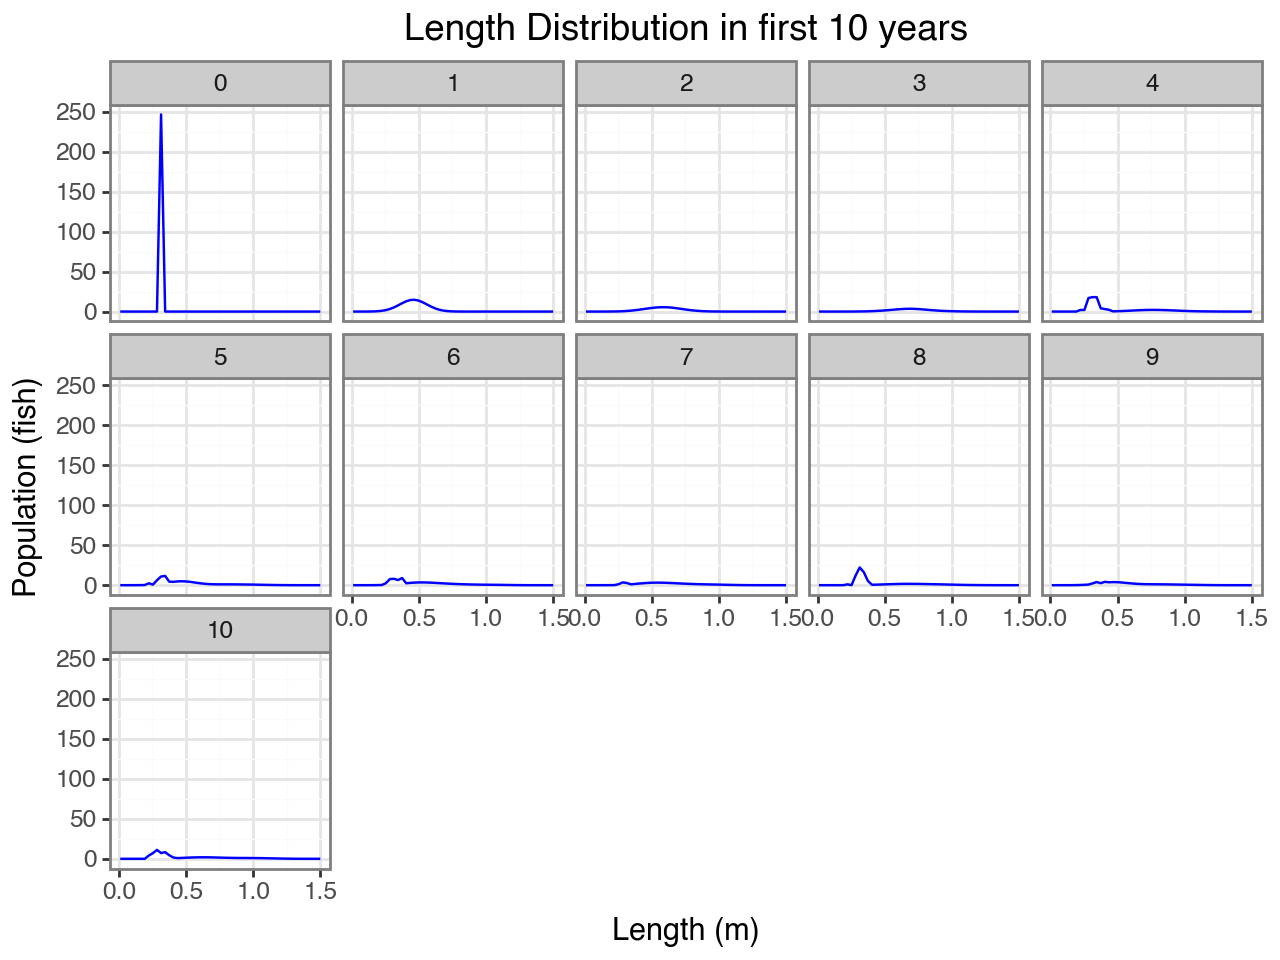

In [47]:
total_pop = pd.DataFrame(out) * delta_z
total_pop["Length"] = length_mesh
total_pop_long = total_pop.melt(id_vars="Length", var_name="Year", value_name="Population")

# Filter the data for the first 10 years
total_pop_long_10_years = total_pop_long[total_pop_long['Year'].astype(int) <= 10]

# Initialize the FacetGrid object
plot = (
    p9.ggplot(total_pop_long_10_years, p9.aes(x="Length", y="Population")) +
    p9.geom_line(color='blue') +
    p9.facet_wrap('~Year', ncol=5) +
    p9.theme(subplots_adjust={'wspace': 0.25, 'hspace': 0.25}) +
    p9.labs(x="Length (m)", y="Population (fish)", title="Length Distribution in first 10 years") +
    p9.theme_bw()
)
plot.show()

### 3.4 Total Population Over Time

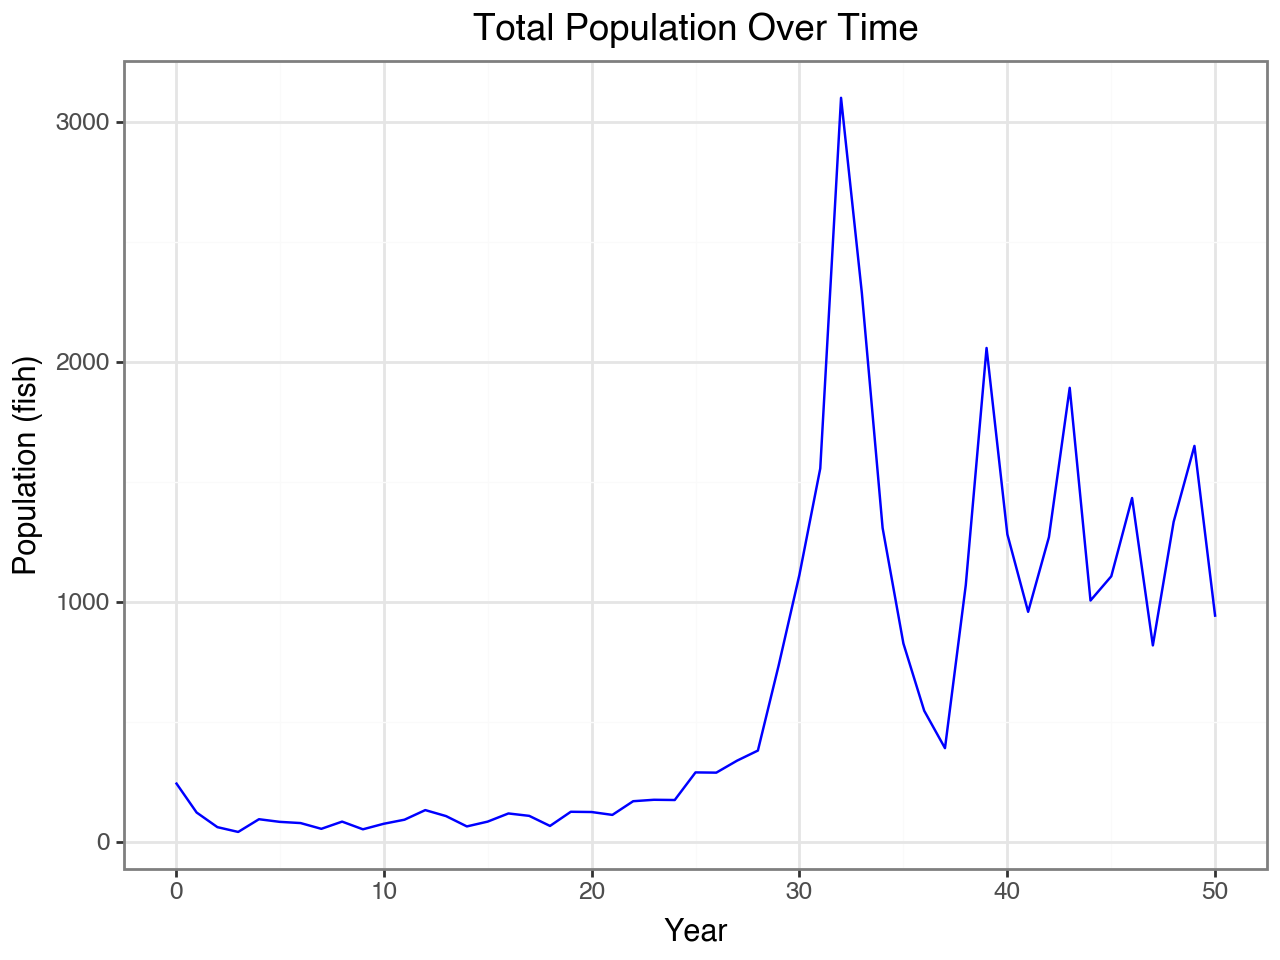

In [48]:
total_pop_sum = total_pop_long.groupby("Year").aggregate(["sum"]).drop(axis=1, labels="Length")
total_pop_sum.columns = total_pop_sum.columns.droplevel(1)
total_pop_sum = total_pop_sum.reset_index()

# Create the plot
plot = (
    p9.ggplot(total_pop_sum, p9.aes(x="Year", y="Population")) +
    p9.geom_line(color='blue') +
    p9.theme(subplots_adjust={'wspace': 0.25, 'hspace': 0.25})+
    p9.labs(x="Year", y="Population (fish)", title="Total Population Over Time") +
    p9.theme_bw()
)
plot.show()

## 4. Stochastic Population Trajectores - Figure 2

Sample paths and the mean (± SE) of the stochastic model for an initial population of female Silver Carp at the Allee threshold. Solid lines show five sample paths; the dashed line shows the stochastic mean; the dotted line marks the threshold. The companion histogram shows the distribution of population sizes at $t = 50$.

### 4.1 Settings

In [ ]:
n_iter = 1000
# Allee Threshold
C = C_mid
# Figure 2AB: 
init_pop = { "initial population": np.array([n0_fish_adult]), 
                "length (m)": np.array([ave_length_adult])}
# Uncomment for different initial population scenarios:
# Figure 2CD: 
# init_pop = { "initial population": np.array([n0_fish_subadult]), 
#                "length (m)": np.array([ave_length_subadult])}
# Figure 2EF: 
# init_pop = { "initial population": np.array([n0_fish_adult]), 
#                "length (m)": np.array([ave_length_subadult])}

### 4.2 Model Run

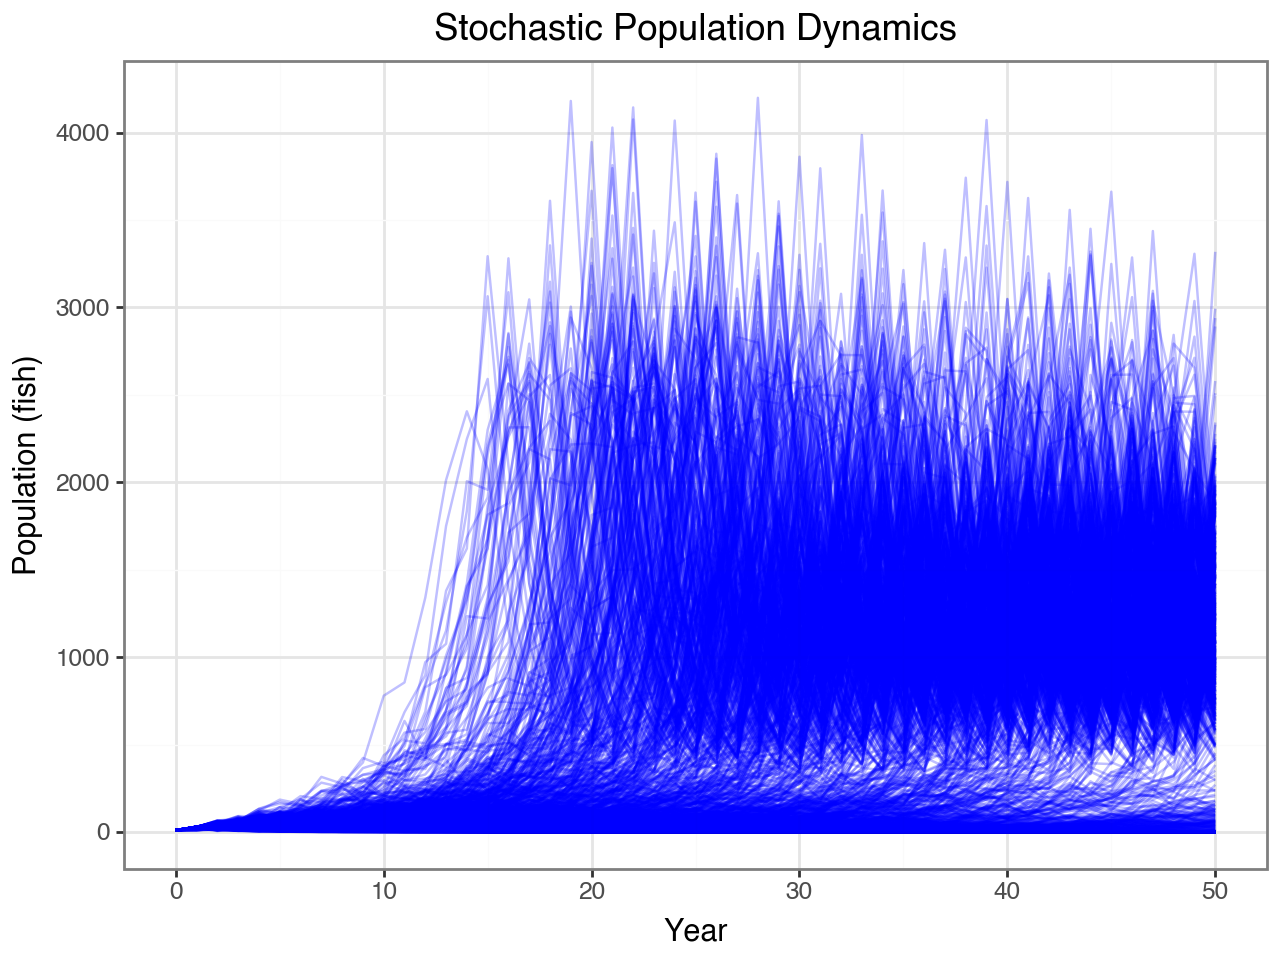

In [50]:
out = ipma.stoch_wrapper(
    p_survive = p_survive,
    p_mature = svcp_mat,
    lw_input = svcp_lw,
    gamma = gamma,
    C = C,
    K = K,
    k = 2,
    min_len = min_len,
    max_len = max_len,
    n_len = n_len,
    n_time = n_time,
    n_iter = n_iter,
    length_mesh = length_mesh,
    growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh),
    yoy_mean = 0.319,
    yoy_sd = 0.040,
    init_pop = init_pop
    )

out = out.reset_index()
plot = (
    p9.ggplot(out, p9.aes(x="Year", y="Population", group="iter")) +
    p9.geom_line(alpha=0.25, color='blue') +
    p9.theme(figure_size=(6, 4))+
    p9.labs(x="Year", y="Population (fish)", title="Stochastic Population Dynamics") +
    p9.theme_bw()
)
plot.show()

### Figure 2ACE -- Sample Paths with Mean

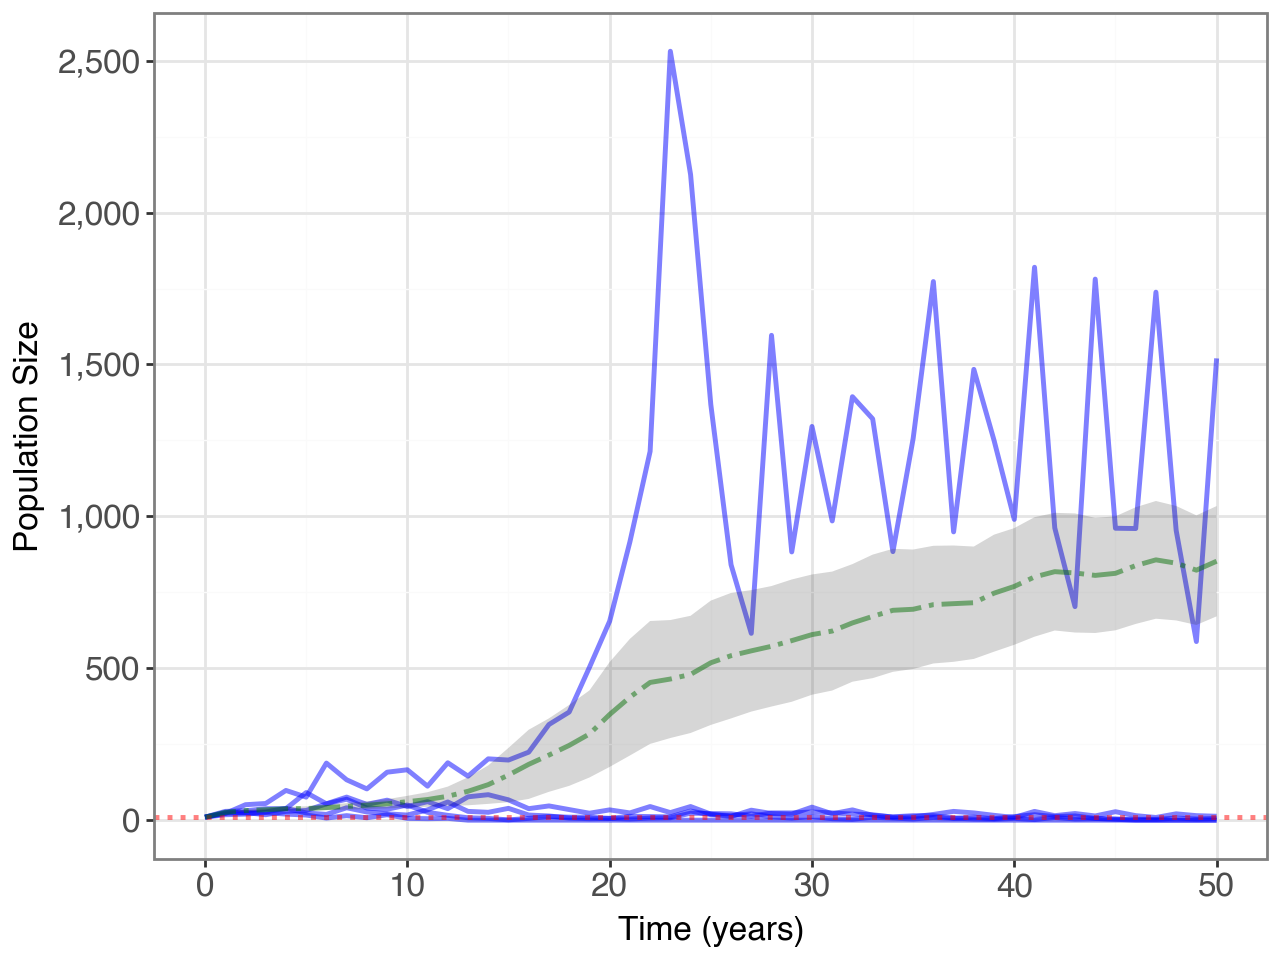

In [51]:
sampled_iters = out['iter'].sample(n=5, random_state=3).unique()

# Filter the data for the sampled iterations
sampled_data = out[out['iter'].isin(sampled_iters)]

# Calculate the mean and standard deviation for each time point
mean_population = out.groupby('Year')['Population'].mean().reset_index()
sd_population = out.groupby('Year')['Population'].std().reset_index()

# Calculate the 95% prediction interval
mean_population['lower'] = np.maximum(0, mean_population['Population'] - 1.96 * sd_population['Population'] / np.sqrt(len(out['Year'].unique())))
mean_population['upper'] = mean_population['Population'] + 1.96 * sd_population['Population'] / np.sqrt(len(out['Year'].unique()))


# Create the plot
plot = (
    p9.ggplot(sampled_data, p9.aes(x="Year", y="Population", group="iter")) +
    p9.geom_line(alpha=0.5, color='blue', size = 1) +
    p9.geom_hline(yintercept=n0_fish_adult, linetype='dotted', color='red', alpha=0.5, size=1) +
    p9.geom_line(mean_population, p9.aes(x="Year", y="Population"), linetype='dashdot', color='green', alpha=0.5, size=1) +
    p9.geom_ribbon(mean_population, p9.aes(ymin='lower', ymax='upper'), alpha=0.2) +
    p9.scale_y_continuous(labels=lambda x: [f"{val:,.0f}" for val in x]) +  # Format y-axis with commas for thousands
    p9.theme(figure_size=(6, 4)) +
    p9.theme_bw() +
    p9.theme(axis_text_x=p9.element_text(size=12),  # Increase x-axis tick label size
             axis_text_y=p9.element_text(size=12),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12)) +  # Increase y-axis tick label s
    p9.labs(
        #title="Population Dynamics with Initial Population and Mean Population",
        x="Time (years)",
        y="Population Size"
    )
)

plot.show()

In [52]:
#plot.save("figures/pop_n0isC_adult.png", dpi=300)
#plot.save("figures/pop_n0isC_juv.png", dpi=300)
#plot.save("figures/pop_n0isadult_juv.png", dpi=300)

### 4.4 Figure 2BDF -- Population Distribution at $t=50$

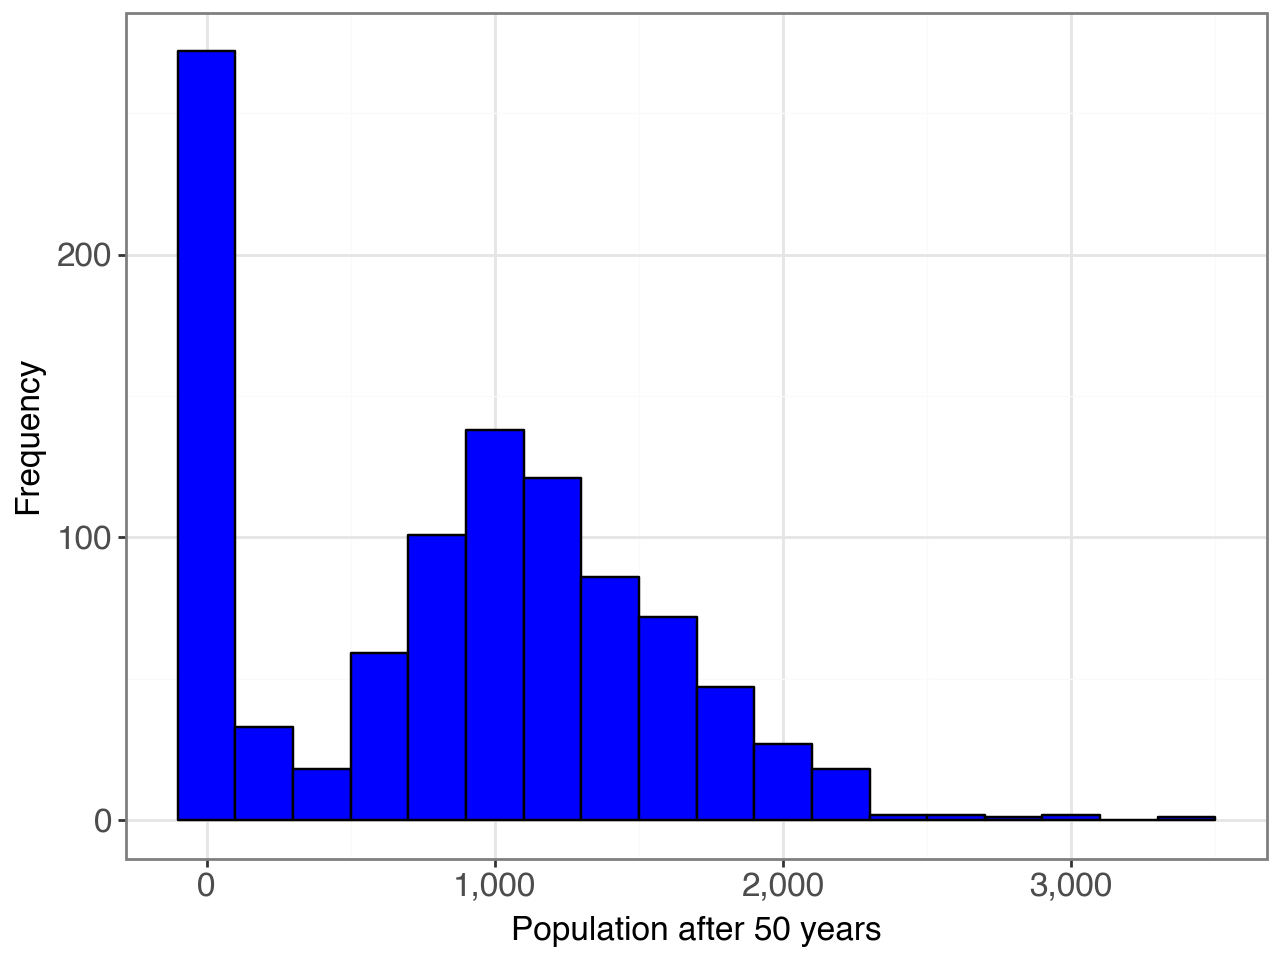

invasion
established        791
non-established    209
dtype: int64


In [54]:
# Extract the population at time n_time for each iteration
population_at_end = out[out['Year'] == n_time][['iter', 'Population']]

plot = (
    p9.ggplot(population_at_end, p9.aes(x="Population")) +
    p9.geom_histogram(binwidth=200.0, fill='blue', color = "black") +
    p9.scale_x_continuous(labels=lambda x: [f"{val:,.0f}" for val in x]) +  # Format y-axis with commas for thousands
    p9.theme(figure_size=(6, 4)) +
    p9.theme_bw() +
    p9.theme(axis_text_x=p9.element_text(size=12),  # Increase x-axis tick label size
             axis_text_y=p9.element_text(size=12),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12)) +  # Increase y-axis tick label s

    p9.labs(
      #  title="Histogram of Population Size after 50 years",
        x="Population after 50 years",
        y="Frequency"
    ) 
)
plot.show()

out_condlist = [population_at_end["Population"] > 10,
                  population_at_end["Population"] <= 10 ]
choicelist = ["established", "non-established"]
population_at_end["invasion"] = np.select(out_condlist, choicelist, default="")
print(population_at_end.groupby("invasion").size())

In [18]:
#plot.save("figures/pop50_n0isC_adult.png", dpi=300)
#plot.save("figures/pop50_n0isC_juv.png", dpi=300)
#plot.save("figures/pop50_n0isadult_juv.png", dpi=300)


## 5 Probability of Establishment -- Figure 3A
Probability of establishing a population of $\geq$ 1,000 female fish within 20 years, as a function of initial propagule size (1–131 adult females), for three Allee thresholds ($C =$ 10, 50, 100 adult fish equivalents).

### 5.1 Settings:

In [64]:
n_time = 20
C_low = ave_weight_adult*10
C_mid = ave_weight_adult*50
C_high = ave_weight_adult*100
n_iter = 100

init_pop = { "initial population": np.array([n0_fish_adult]), 
                "length (m)": np.array([ave_length_adult])}

### 5.2 Model Run

In [63]:
# Define the values of C
C_values = [C_low, C_mid, C_high]
C_labels = ["C=10", "C=50", "C=100"]
line_styles = ['dotted', 'dashed', 'solid']
markers = ['^', 's', 'o']

colorblind_palette = ["#E69F00", "#17191A", "#009E73"]

# Initialize a list to store the results
results = []

# Loop through each value of C
for C, label, line_style, marker in zip(C_values, C_labels, line_styles, markers):
    prob_establishment_values = []
    for n0_fish in np.arange(1, 132, 5): # for adults
#    for n0_fish in np.arange(30, 1530, 100): # for juv
        out = ipma.stoch_wrapper(
            p_survive = p_survive,
            p_mature = svcp_mat,
            lw_input = svcp_lw,
            gamma = gamma,
            C = C,
            K = K,
            k = 2,
            min_len = min_len,
            max_len = max_len,
            n_len = n_len,
            n_time = n_time,
            n_iter = n_iter,
            length_mesh = length_mesh,
            growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh),
            yoy_mean = 0.319,
            yoy_sd = 0.040,
            init_pop = init_pop
        )
        out = out.reset_index()

        # Extract the population at time n_time for each iteration
        population_at_end = out[out['Year'] == n_time][['iter', 'Population']]

        out_condlist = [population_at_end["Population"] >= 1000,
                        population_at_end["Population"] < 1000]
        choicelist = ["established", "non-established"]
        population_at_end["invasion"] = np.select(out_condlist, choicelist, default="")

        prob_establishment = population_at_end["invasion"].value_counts().get("established", 0)/len(population_at_end)
        prob_establishment_values.append(prob_establishment)

    # Store the results in a DataFrame
    results.append(pd.DataFrame({
        'n0_fish': np.arange(1, 132, 5),
    #    'n0_fish': np.arange(30, 1530, 100),
        'prob_establishment': prob_establishment_values,
        'C': label,
        'line_style': line_style,
        'marker': marker,
        'fill_style': 'none'
    }))

# Concatenate all results into a single DataFrame
results_df = pd.concat(results)


### 5.3 Figure 3A

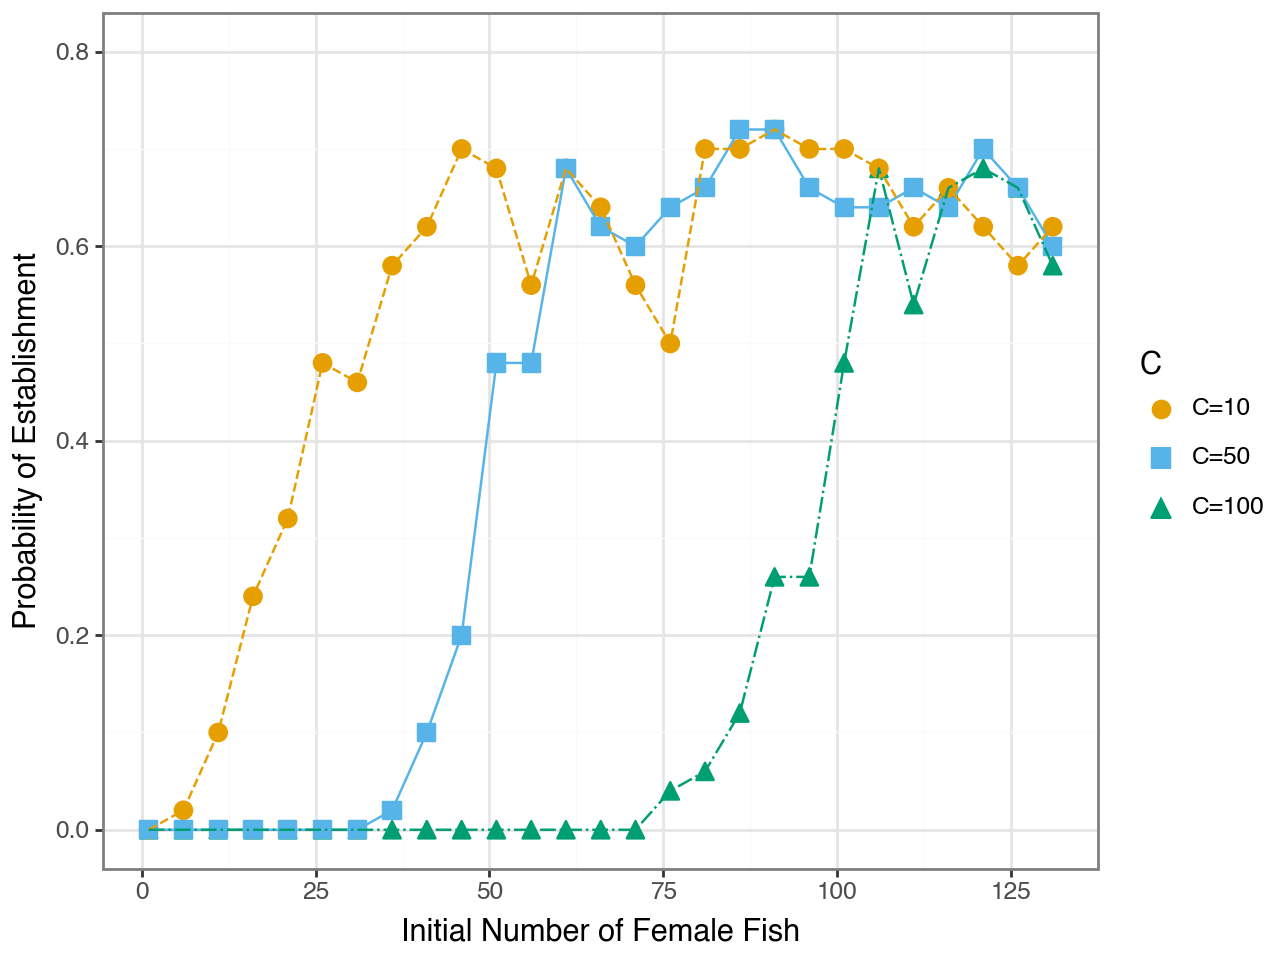

In [21]:

# Assuming the unique values are integers or strings without "C="
# Convert the 'C' column to a categorical type with specified levels
results_df['C'] = pd.Categorical(results_df['C'], categories=["C=10", "C=50", "C=100"], ordered=True)

# Define colorblind_palette and markers if not already defined
#colorblind_palette = ["#0072B2", "#D55E00", "#009E73"]  # Example colors
colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]
markers = ["o", "s", "^"]  # Example markers

# Plot the results
plot = (
    p9.ggplot(results_df, p9.aes(x='n0_fish', y='prob_establishment', color='C', shape='C')) +
    p9.geom_point(size=3, show_legend=True) +
    p9.geom_line(p9.aes(linetype='line_style'), show_legend=False) +
    p9.scale_color_manual(values=colorblind_palette, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.scale_shape_manual(values=markers, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.labs(
        x="Initial Number of Female Fish",
        y="Probability of Establishment"
    ) +
    p9.ylim(0, 0.8) +
    p9.scale_x_continuous(breaks=range(0, int(results_df['n0_fish'].max()) + 25, 25)) +  # Set x-axis ticks every 25
    p9.theme(legend_title=p9.element_blank(),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12))+
    p9.theme_bw() 
)

plot.show()

In [22]:
#plot.save("figures/probE_adult.png", dpi=300)

## 6. Time to Establishment -- Figure 3B

Mean time (± SD) in years to reach $\geq$ 1,000 female fish, as a function of initial propagule size, for $C =$ 10, 50, and 100. Only trials that reached the threshold within the simulation window are included in the mean.

### 6.1 New Functions
These functions extend the module with early-exit logic not needed elsewhere.

In [57]:
def grow_select(growth_matrix, pop_vec_in):
    # Extract growth probs
    grow_pop_pos = growth_matrix[np.where(pop_vec_in > 0)[0], :] # selects all growth columns where pop>0
    # Create array to hold outputs
    new_pop_array = np.zeros(grow_pop_pos.shape[1])
  #  delta_z = np.diff(length_mesh)[0]

    # Loop through growth columns
    for g_idx in range(grow_pop_pos.shape[0]):
        # select new growth bins
        new_pop_array += np.random.multinomial(pop_vec_in[pop_vec_in>0][g_idx], grow_pop_pos[g_idx])
    return new_pop_array


def ipm_bm_allee_time(
    p_survive,
    p_mature,
    lw_input,
    gamma,
    C,
    K,
    k,
    min_len,
    max_len,
    n_len,
    n_time,
    n_iter,
    length_mesh,
    growth_matrix,
    yoy_mean,
    yoy_sd,
    init_pop):
    if length_mesh is None:
        length_mesh = np.linspace(min_len, max_len, n_len)

    if growth_matrix is None:
        growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh)
        
    delta_z = np.diff(length_mesh)[0] # width of length bin
    # Convert input lengths to mesh bins
    bins = np.digitize(init_pop["length (m)"], length_mesh, right=True)
    pop_dens = np.zeros([n_len, n_time + 1])
    # for needed if multiple lengths in same bin
    for idx in range(len(bins)):
        pop_dens[bins[idx], 0] += init_pop["initial population"][idx]
    # Normalize to ensure the sum equals the initial population
    pop_dens[:, 0] *= init_pop["initial population"].sum() / (pop_dens[:, 0] * delta_z).sum()

    yoy_place_raw = stats.norm.pdf(x=length_mesh,
                               loc=yoy_mean,
                               scale=yoy_sd)
    yoy_place_den = yoy_place_raw/yoy_place_raw.sum() 
    # create initial condition
      
    for t_idx in range(n_time):
        if (pop_dens[:,t_idx].sum()*delta_z) > 1000:
            return pop_dens
        else:        
            biomass_t = (lw_input.predict_weight(length_mesh) * pop_dens[:, t_idx] * delta_z).sum()
            biomass_tp1 =  biomass_t*np.exp(gamma*(1-biomass_t/K)*( (biomass_t-C)))
            pop_mat_dens = np.array([stats.binom.rvs(n = 1,
                            p = p_mature.maturity_prob(xx),
                            loc=0, size = int(pop_dens[xx, t_idx]),
                            random_state=None).sum() for xx in range(n_len)])
            mature_total = (pop_mat_dens*delta_z).sum() #m_t
            surv_dens =  np.array([stats.binom.rvs(n = 1,
                     p = p_survive.prob_s(length_mesh[xx]),
                     loc=0, size = int(pop_dens[xx, t_idx]),
                     random_state=None).sum() for xx in range(n_len)])
            surv_grow_dens = grow_select(growth_matrix = growth_matrix, pop_vec_in = surv_dens)
            survivor_biomass = (lw_input.predict_weight(length_mesh) * surv_grow_dens * delta_z).sum()
            k_density = np.random.multinomial(int(k), yoy_place_den)/delta_z
            k_biomass = (lw_input.predict_weight(length_mesh)*k_density*delta_z).sum()
            if (biomass_tp1 - survivor_biomass) < 0: # current biomass too great, do not reproduce
                A = 0
            elif (biomass_tp1 - survivor_biomass) > (k_biomass * mature_total): # large gap, all reproduce
                A = 1
            elif k_biomass * mature_total == 0:
                A = 0
            else:
                A = (biomass_tp1 - survivor_biomass) / (k_biomass * mature_total)
            for i in range(len(length_mesh)):
                X_i = pop_dens[i, t_idx] * delta_z
                X_int = int(X_i)  # Integer part (whole fish count)
                X_frac = X_i - X_int  # Fractional part (probabilistic fish)
            
                m = p_mature.maturity_prob(length_mesh[i])  # Probability of maturing at size z
                s = p_survive.prob_s(length_mesh[i])[0]     # Probability of surviving at size z
    
                Xi_0 = (1 - m) * (1 - s) + m * (1 - A) * (1 - s)  
                Xi_1 = (1 - m) * s + m * (1 - A) * s
                Xi_k = m * A * (1 - s)
                Xi_kp1 = m * A * s

                for _ in range(X_int):
                    Xi_select = choices(['0', '1', 'k', 'k+1'], [Xi_0, Xi_1, Xi_k, Xi_kp1])[0]

                # Update population density based on branching outcome
                    if Xi_select == '1':  # Survives and grows
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z)
        
                    elif Xi_select == 'k':  # Spawns and dies
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += yoy / delta_z
        
                    elif Xi_select == 'k+1':  # Survives, grows, and spawns
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z) + yoy / delta_z
                    
            # Handle probabilistic fish if fractional part exists
                if random() < X_frac:
                    Xi_select = choices(['0', '1', 'k', 'k+1'], [Xi_0, Xi_1, Xi_k, Xi_kp1])[0]
        
                    if Xi_select == '1':  # Survives and grows
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z)
        
                    elif Xi_select == 'k':  # Spawns and dies
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += yoy / delta_z
        
                    elif Xi_select == 'k+1':  # Survives, grows, and spawns
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z) + yoy / delta_z    
    
    return pop_dens



In [58]:
def time_to_establishment(
    p_survive,
    p_mature,
    lw_input,
    gamma,
    C,
    K,
    k,
    min_len,
    max_len,
    n_len,
    n_time,
    n_iter,
    length_mesh,
    growth_matrix,
    yoy_mean,
    yoy_sd,
    init_pop):
    
    out = ipm_bm_allee_time(
            p_survive = p_survive,
            p_mature = p_mature,
            lw_input = lw_input,
            gamma = gamma,
            C = C,
            K = K,
            k = k,
            min_len = min_len,
            max_len = max_len,
            n_len = n_len,
            n_time = n_time,
            n_iter = n_iter,
            length_mesh = length_mesh,
            growth_matrix = growth_matrix,
            yoy_mean = yoy_mean,
            yoy_sd = yoy_sd,
            init_pop = init_pop)

    total_pop = pd.DataFrame(out) * delta_z
    total_pop["Length"] = length_mesh
    total_pop_long = total_pop.melt(id_vars="Length", var_name="Year", value_name="Population")

    total_pop_sum = total_pop_long.groupby("Year").aggregate(["sum"]).drop(axis=1, labels="Length")
    total_pop_sum.columns = total_pop_sum.columns.droplevel(1)
    total_pop_sum = total_pop_sum.reset_index()
    
    if not total_pop_sum[total_pop_sum['Population'] == 0].empty:
        return total_pop_sum[total_pop_sum['Population'] == 0].iloc[0,0] # time to establishment
    else:
        return n_time

### 6.2 Settings

In [59]:
n_time = 50
n_iter = 10

n0_fish_adult_values = np.arange(1, 132, 5)

# Define the values of C
C_values = [C_low, C_mid, C_high]
C_labels = ["C=10", "C=50", "C=100"]

### 6.3 Model Run

In [60]:
results = []

for Cval in C_values:
    for n0 in n0_fish_adult_values:
        all_valid_times = []
        for _ in range(50): # run est_time 10 times
            est_time = time_to_establishment(
                p_survive=p_survive,
                p_mature=svcp_mat,
                lw_input=svcp_lw,
                gamma=gamma,
                C=Cval,
                K=K,
                k=2,
                min_len=min_len,
                max_len=max_len,
                n_len=n_len,
                n_time=n_time,
                n_iter=n_iter,
                length_mesh=length_mesh,
                growth_matrix=von_b_growth.growth(length_now=length_mesh, length_next=length_mesh),
                yoy_mean=0.319,
                yoy_sd=0.040,
                init_pop={"initial population": np.array([n0]), "length (m)": np.array([ave_length_adult])}
                )
            if est_time != n_time:
                all_valid_times.append(est_time)
        mean_time = np.mean(all_valid_times)
        sd_time = np.std(all_valid_times)
        results.append((n0, Cval, mean_time, sd_time))

### 6.4 Figure 2B

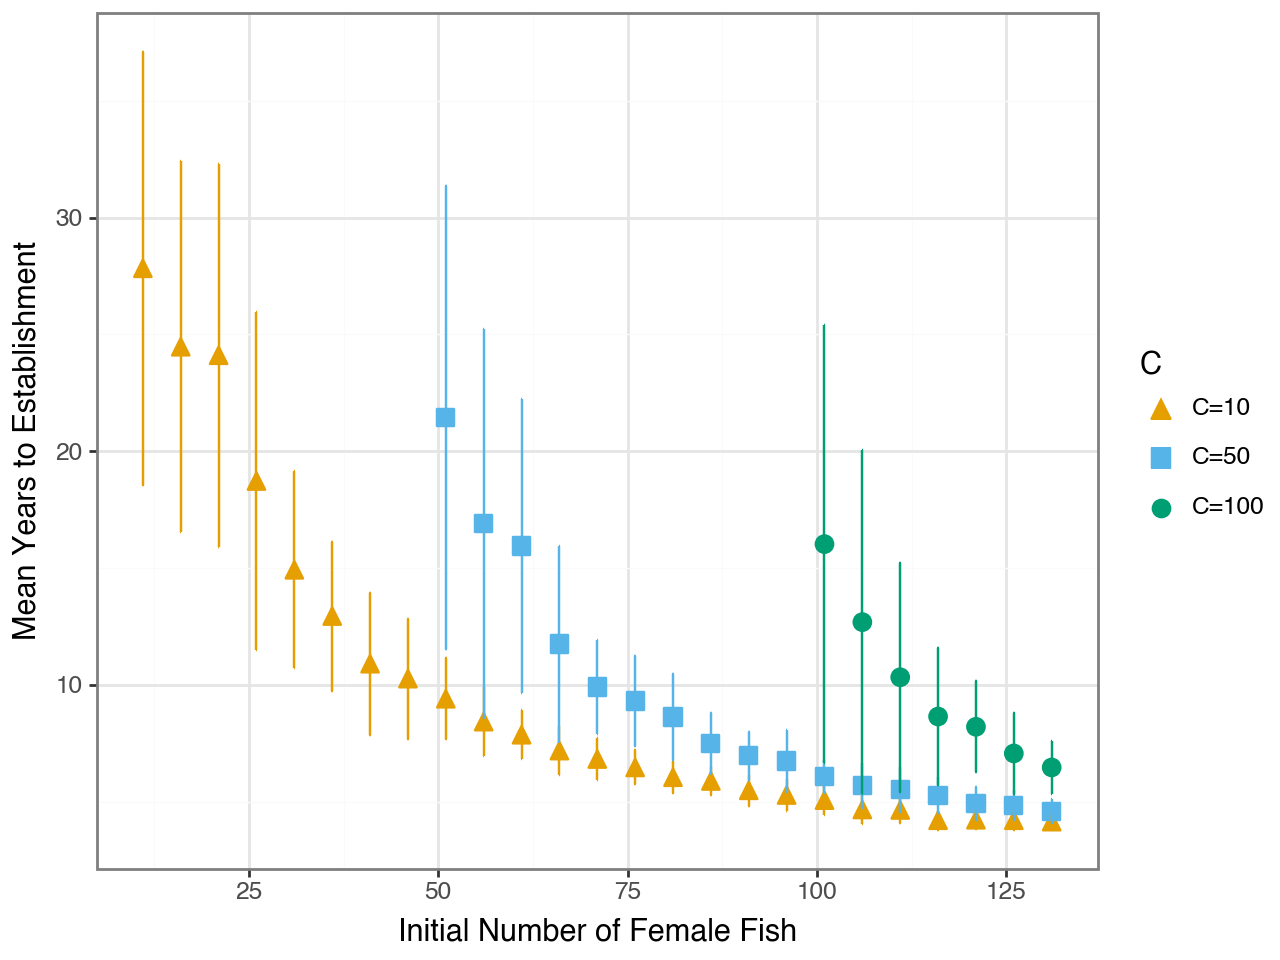

In [61]:
# Create a new DataFrame for plotting
plot_df = pd.DataFrame({
    'n0_fish': [result[0] for result in results],
    'C': [result[1] for result in results],
    'mean_time': [result[2] for result in results],
    'sd_time': [result[3] for result in results],
    'CImoe': [1.96 * (result[3]/np.sqrt(50)) for result in results]
})

C_mapping = {C_low: "C=10", C_mid: "C=50", C_high: "C=100"}
#C_mapping = {104.7: "C=10", 523.5: "C=50", 1047: "C=100"}
plot_df['C'] = plot_df['C'].map(C_mapping)

# Convert the 'C' column to a categorical type with specified levels
plot_df['C'] = pd.Categorical(plot_df['C'], categories=["C=10", "C=50", "C=100"], ordered=True)

# Filter the DataFrame to only include rows where n0_fish > C
plot_df_filtered = plot_df[plot_df.apply(
    lambda row: pd.notna(row['C']) and row['n0_fish'] > float(str(row['C']).split('=')[1]), axis=1
)]

line_styles = ['dotted', 'dashed', 'solid']
markers = ['^', 's', 'o']
colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]
#colorblind_palette = ["#0072B2", "#D55E00", "#009E73"]  # Example colors

# Plot the results
plot = (
    p9.ggplot(plot_df_filtered, p9.aes(x='n0_fish', y='mean_time', color='C', shape='C')) +
    p9.geom_point(size=3, show_legend=True) +
    p9.geom_errorbar(p9.aes(ymin='mean_time - sd_time', ymax='mean_time + sd_time'), width=0.2, show_legend=False) +
    p9.scale_color_manual(values=colorblind_palette, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.scale_shape_manual(values=markers, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.labs(
        x="Initial Number of Female Fish",
        y="Mean Years to Establishment"
    ) +
    p9.scale_x_continuous(breaks=range(0, int(plot_df_filtered['n0_fish'].max()) + 25, 25)) +  # Set x-axis ticks every 25
    p9.scale_y_continuous(breaks=range(0, 60, 10)) +  # Set y-axis ticks every 10
    p9.theme_bw() +
    p9.theme(legend_title=p9.element_blank(),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12))+
    p9.theme_bw() 
)

plot.show()

In [ ]:
#plot.save("figures/time2E.png", dpi=300)

/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/time2E.png


## 7 Sensitivity Analysis — Effect of Fecundity Parameter k
The parameter k controls the number of young-of-year produced per spawning event. Here we hold the Allee threshold fixed at $C = 50$ and vary $k \in {1, 5, 10}$ to assess how fecundity interacts with propagule size to determine establishment outcomes.

### 7.1 Probability of Establishment vs. k -- Figure 4A

#### 7.1.1 Settings

In [ ]:
n_time = 20
k_low = 1
k_mid = 5
k_high = 10
n_iter = 50
C = C_mid

#### 7.1.2 Model Run

In [ ]:
# Define the values of k
k_values = [k_low, k_mid, k_high]
k_labels = ["k=1", "k=5", "k=10"]
line_styles = ['dotted', 'dashed', 'solid']
markers = ['^', 's', 'o']

colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]

# Initialize a list to store the results
results = []

# Loop through each value of k
for k, label, line_style, marker in zip(k_values, k_labels, line_styles, markers):
    prob_establishment_values = []
    for n0_fish in np.arange(1, 132, 5): # for adults
#    for n0_fish in np.arange(30, 1530, 100): # for juv
        out = ipma.stoch_wrapper(
            p_survive = p_survive,
            p_mature = svcp_mat,
            lw_input = svcp_lw,
            gamma = gamma,
            C = C,
            K = K,
            k = k,
            min_len = min_len,
            max_len = max_len,
            n_len = n_len,
            n_time = n_time,
            n_iter = 50,
            length_mesh = length_mesh,
            growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh),
            yoy_mean = 0.319,
            yoy_sd = 0.040,
            init_pop = { "initial population": np.array([n0_fish]), "length (m)": np.array([1.0])})

        out = out.reset_index()

        # Extract the population at time n_time for each iteration
        population_at_end = out[out['Year'] == n_time][['iter', 'Population']]

        out_condlist = [population_at_end["Population"] >= 1000,
                        population_at_end["Population"] < 1000]
        choicelist = ["established", "non-established"]
        population_at_end["invasion"] = np.select(out_condlist, choicelist, default="")

        prob_establishment = population_at_end["invasion"].value_counts().get("established", 0)/len(population_at_end)
        prob_establishment_values.append(prob_establishment)

    # Store the results in a DataFrame
    results.append(pd.DataFrame({
        'n0_fish': np.arange(1, 132, 5),
    #    'n0_fish': np.arange(30, 1530, 100),
        'prob_establishment': prob_establishment_values,
        'k': label,
        'line_style': line_style,
        'marker': marker,
        'fill_style': 'none'
    }))

# Concatenate all results into a single DataFrame
results_df = pd.concat(results)

#### 7.1.3 Figure 4A

/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


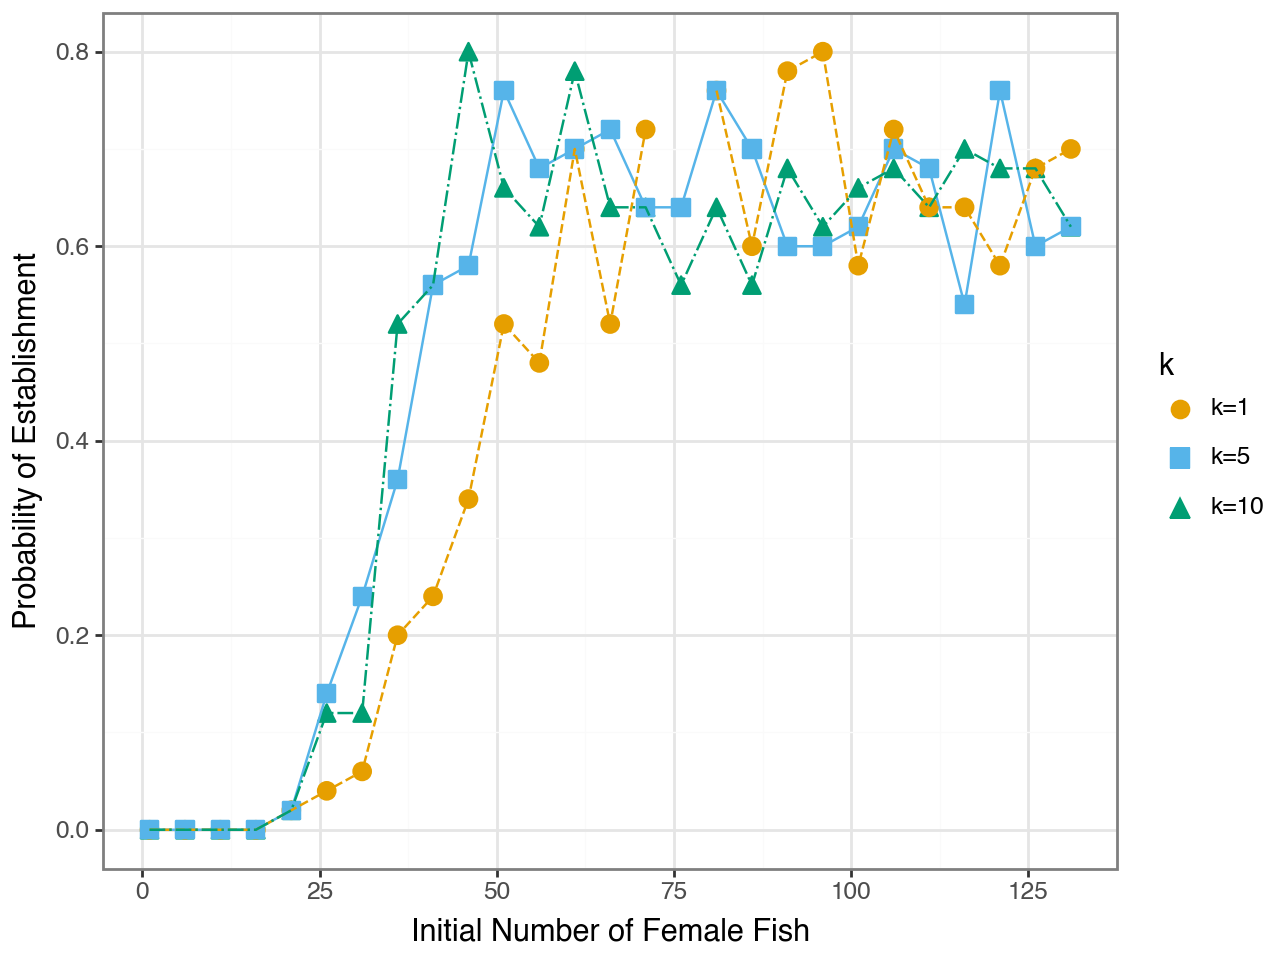

In [ ]:
# Assuming the unique values are integers or strings without "k="
# Convert the 'k' column to a categorical type with specified levels
results_df['k'] = pd.Categorical(results_df['k'], categories=["k=1", "k=5", "k=10"], ordered=True)

# Define colorblind_palette and markers if not already defined
#colorblind_palette = ["#0072B2", "#D55E00", "#009E73"]  # Example colors
colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]
markers = ["o", "s", "^"]  # Example markers

# Plot the results
plot = (
    p9.ggplot(results_df, p9.aes(x='n0_fish', y='prob_establishment', color='k', shape='k')) +
    p9.geom_point(size=3, show_legend=True) +
    p9.geom_line(p9.aes(linetype='line_style'), show_legend=False) +
    p9.scale_color_manual(values=colorblind_palette, breaks=["k=1", "k=5", "k=10"], labels=['k=1', 'k=5', 'k=10']) +
    p9.scale_shape_manual(values=markers, breaks=["k=1", "k=5", "k=10"], labels=['k=1', 'k=5', 'k=10']) +
    p9.labs(
        x="Initial Number of Female Fish",
        y="Probability of Establishment"
    ) +
    p9.ylim(0, 0.8) +
    p9.scale_x_continuous(breaks=range(0, int(results_df['n0_fish'].max()) + 25, 25)) +  # Set x-axis ticks every 25
    p9.theme(legend_title=p9.element_blank(),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12))+
    p9.theme_bw() 
)

plot.show()

In [ ]:
#plot.save("figures/probE_adult_vs_k.png", dpi=300)

/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/probE_adult_vs_k.png
/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


### 7.2 Time to Establishment vs. k -- Figure 4B

#### 7.2.1 Settings

In [ ]:
n_time=50
n_iter=10

n0_fish_adult_values = np.arange(1, 132, 5)

# Define the values of C
k_values = [k_low, k_mid, k_high]
k_labels = ["k=1", "k=5", "k=10"]

#### 7.2.2 Model Run

In [ ]:
results = []

for kval in k_values:
    for n0 in n0_fish_adult_values:
        all_valid_times = []
        for _ in range(50): # run est_time 10 times
            est_time = time_to_establishment(
                p_survive=p_survive,
                p_mature=svcp_mat,
                lw_input=svcp_lw,
                gamma=gamma,
                C=C,
                K=K,
                k=kval,
                min_len=min_len,
                max_len=max_len,
                n_len=n_len,
                n_time=60,
                n_iter=10,
                length_mesh=length_mesh,
                growth_matrix=von_b_growth.growth(length_now=length_mesh, length_next=length_mesh),
                yoy_mean=0.319,
                yoy_sd=0.040,
                init_pop={"initial population": np.array([n0]), "length (m)": np.array([ave_length_adult])}
                )
            if est_time != n_time:
                all_valid_times.append(est_time)
        mean_time = np.mean(all_valid_times)
        sd_time = np.std(all_valid_times)
        results.append((n0, kval, mean_time, sd_time))

#### 7.2.3 Figure 4B

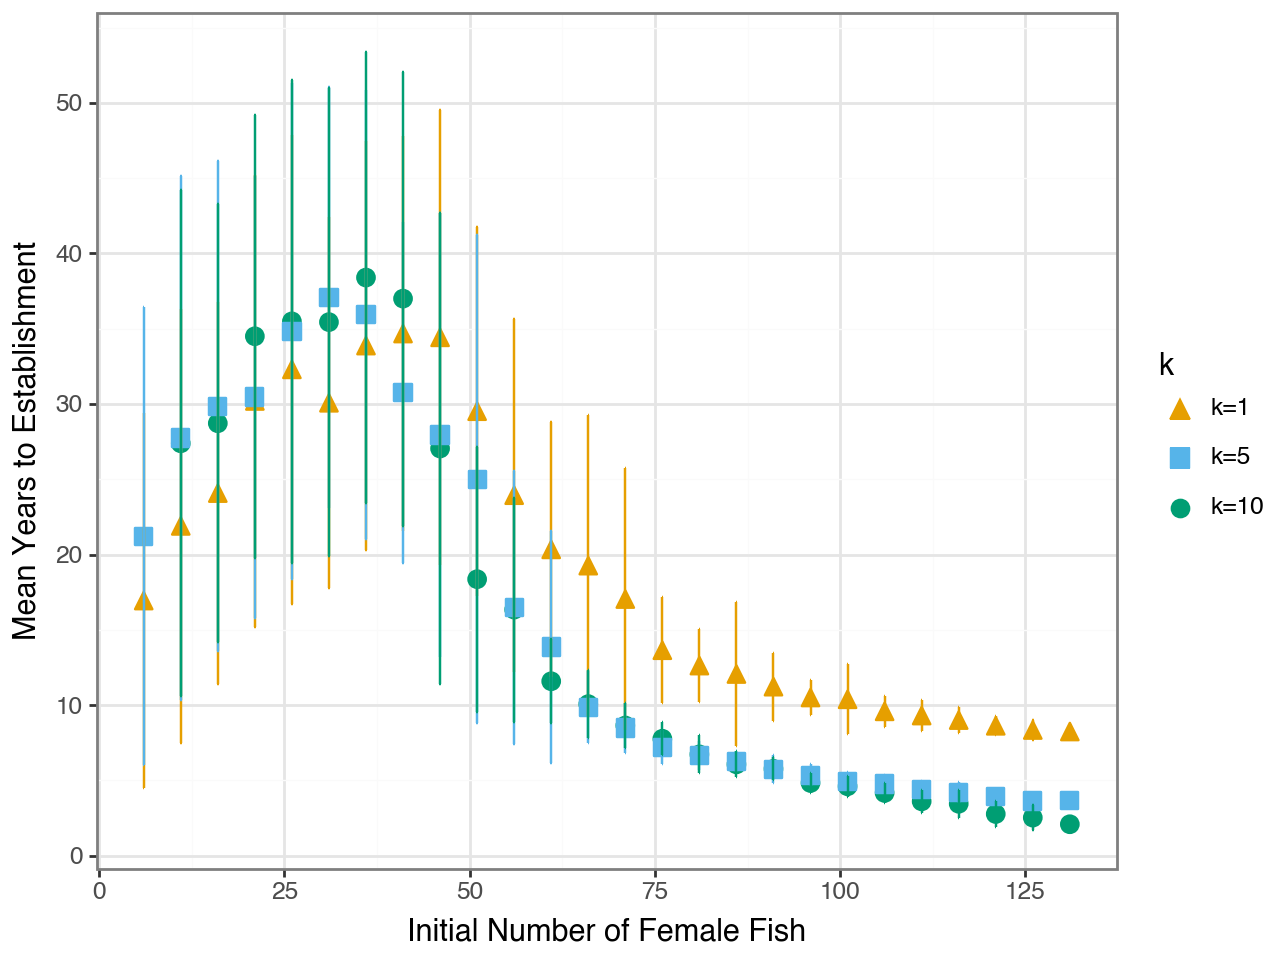

In [ ]:
# Create a new DataFrame for plotting
plot_df = pd.DataFrame({
    'n0_fish': [result[0] for result in results],
    'k': [result[1] for result in results],
    'mean_time': [result[2] for result in results],
    'sd_time': [result[3] for result in results],
    'kImoe': [1.96 * (result[3]/np.sqrt(50)) for result in results]
})

k_mapping = {k_low: "k=1", k_mid: "k=5", k_high: "k=10"}
#k_mapping = {1: "k=1", 5: "k=5", 10: "k=10"}
plot_df['k'] = plot_df['k'].map(k_mapping)

# Convert the 'k' column to a categorical type with specified levels
plot_df['k'] = pd.Categorical(plot_df['k'], categories=["k=1", "k=5", "k=10"], ordered=True)

# Filter the DataFrame to only include rows where n0_fish > k
plot_df_filtered = plot_df[plot_df.apply(
    lambda row: pd.notna(row['k']) and row['n0_fish'] > float(str(row['k']).split('=')[1]), axis=1
)]

line_styles = ['dotted', 'dashed', 'solid']
markers = ['^', 's', 'o']
colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]
#colorblind_palette = ["#0072B2", "#D55E00", "#009E73"]  # Example colors

# Plot the results
plot = (
    p9.ggplot(plot_df_filtered, p9.aes(x='n0_fish', y='mean_time', color='k', shape='k')) +
    p9.geom_point(size=3, show_legend=True) +
    p9.geom_errorbar(p9.aes(ymin='mean_time - sd_time', ymax='mean_time + sd_time'), width=0.2, show_legend=False) +
    p9.scale_color_manual(values=colorblind_palette, breaks=["k=1", "k=5", "k=10"], labels=['k=1', 'k=5', 'k=10']) +
    p9.scale_shape_manual(values=markers, breaks=["k=1", "k=5", "k=10"], labels=['k=1', 'k=5', 'k=10']) +
    p9.labs(
        x="Initial Number of Female Fish",
        y="Mean Years to Establishment"
    ) +
    p9.scale_x_continuous(breaks=range(0, int(plot_df_filtered['n0_fish'].max()) + 25, 25)) +  # Set x-axis ticks every 25
    p9.scale_y_continuous(breaks=range(0, 60, 10)) +  # Set y-axis ticks every 10
    p9.theme_bw() +
    p9.theme(legend_title=p9.element_blank(),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12))+
    p9.theme_bw() 
)

plot.show()

In [ ]:
#plot.save("figures/time2E_vs_k.png", dpi=300)

/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/jpeirce/Documents/research/branching-process/branchingIPM_PLOS/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/time2E_vs_k.png


## 8. Reproducibility:

In [ ]:
import sys
print(sys.version)

In [ ]:
!conda list